<a href="https://colab.research.google.com/github/cocyten27/MODULE_6/blob/main/M6_L19_whisper_asr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TAE-IA · Module 6 · L19 — Speech Recognition with Whisper: Audio to Text

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L19 |
| **Track** | B — Audio |
| **Runtime** | T4 GPU (speeds up Whisper ~4–6×) |
| **Drive space** | ~2 GB new (Whisper small + medium weights) |

## Learning objectives

By the end of this notebook you will be able to:
1. Load Whisper models of different sizes and understand the speed/accuracy trade-off
2. Transcribe audio in English and Spanish with automatic language detection
3. Force a language or switch to translation mode with `task="translate"`
4. Compute WER using `jiwer` with correct normalisation
5. Build a model-size comparison table (tiny / small / medium) on multiple audio conditions

---

## Cell 0 — Setup

In [1]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, random, time
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/TAE_IA_M6/models'
os.makedirs(MODEL_CACHE, exist_ok=True)

os.environ['HF_HOME']            = MODEL_CACHE
os.environ['TORCH_HOME']         = MODEL_CACHE
os.environ['TRANSFORMERS_CACHE'] = os.path.join(MODEL_CACHE, 'hub')

# openai-whisper does NOT read TORCH_HOME -- left to itself it caches to
# ~/.cache/whisper on the ephemeral runtime disk. Every load_model() call
# below passes download_root=WHISPER_CACHE explicitly; that is what puts the
# weights on Drive and lets L20 reuse them without re-downloading.
WHISPER_CACHE = MODEL_CACHE

SEED = 42
random.seed(SEED); np.random.seed(SEED)

import torch
if not torch.cuda.is_available():
    print('\nNo GPU — go to Runtime > Change runtime type > T4 GPU')
    print('Whisper will still run on CPU but ~4× slower.')
else:
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Mounted at /content/drive
GPU: Tesla T4
VRAM: 15.6 GB
Device: cuda


In [3]:
!pip install openai-whisper jiwer gtts pydub librosa soundfile -q

import whisper
from jiwer import wer, process_words
from gtts import gTTS
import librosa
import matplotlib.pyplot as plt
import IPython.display as ipd

print(f'whisper {whisper.__version__}')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

whisper 20250625


---
## Section 2.1 — Generate Test Audio Files

We use `gTTS` (Google Text-to-Speech) to synthesise test audio with **exactly known ground truth text**. This makes WER measurement unambiguous — no manual transcription required.

| Condition | Why it matters |
|---|---|
| Clear English | Baseline — should give near-zero WER |
| Clear Spanish | Tests multilingual capability |
| Fast English | gTTS `slow=False` produces faster delivery |
| Technical terms | Numbers, domain words (mel spectrogram, etc.) |
| Noisy English | Add white noise at different SNRs — tests robustness |

In [4]:
AUDIO_DIR = '/tmp/L19_audio'
os.makedirs(AUDIO_DIR, exist_ok=True)

# Ground truth references — keep lowercase, no punctuation (for WER)
REFERENCES = {
    'clear_en':  'the artificial intelligence model processes audio signals in real time',
    'clear_es':  'la inteligencia artificial procesa señales de audio en tiempo real',
    'fast_en':   'machine learning models learn patterns from large amounts of training data',
    'technical': 'the mel spectrogram uses one hundred twenty eight frequency bands',
    'noisy_en':  'the artificial intelligence model processes audio signals in real time',
}

# gTTS text (with punctuation for natural TTS prosody; reference is lowercase/stripped)
TTS_TEXT = {
    'clear_en':  ('The artificial intelligence model processes audio signals in real time.', 'en', False),
    'clear_es':  ('La inteligencia artificial procesa señales de audio en tiempo real.', 'es', False),
    'fast_en':   ('Machine learning models learn patterns from large amounts of training data.', 'en', False),
    'technical': ('The mel spectrogram uses one hundred twenty eight frequency bands.', 'en', False),
    'noisy_en':  ('The artificial intelligence model processes audio signals in real time.', 'en', False),
}

# The clips ship as a zip on Drive. Thirty students calling Google's TTS in the
# same thirty seconds is a rate-limit waiting to happen, and identical clips also
# make every team's WER table comparable with the answer key. When the bundle is
# missing we generate them live instead -- same sentences, same call, made now.
import zipfile

AUDIO_ZIP_CANDIDATES = [
    '/content/drive/MyDrive/TAE_IA_M6/assets/L19_audio.zip',
    '/content/drive/MyDrive/TAE_IA_M6/L19_audio.zip',
]
bundle = next((p for p in AUDIO_ZIP_CANDIDATES if os.path.exists(p)), None)
if bundle:
    with zipfile.ZipFile(bundle) as zf:
        zf.extractall(AUDIO_DIR)
    print(f'Clips: extracted from {bundle}')
else:
    print('Clips: no bundle on Drive, generating with gTTS (needs internet).')

for name, (text, lang, slow) in TTS_TEXT.items():
    mp3_path = os.path.join(AUDIO_DIR, f'{name}.mp3')
    if not os.path.exists(mp3_path):        # absent from the bundle, or no bundle
        tts = gTTS(text=text, lang=lang, slow=slow)
        tts.save(mp3_path)
    print(f'  {name}: {mp3_path}')

# Add noise to noisy_en by mixing with white noise
y_clean, sr = librosa.load(os.path.join(AUDIO_DIR, 'noisy_en.mp3'), sr=16000, mono=True)
rng = np.random.default_rng(SEED)
# SNR ~ 5 dB — perceptibly noisy but still intelligible
signal_power = np.mean(y_clean ** 2)
noise_power  = signal_power / (10 ** (5 / 10))
noise        = rng.normal(0, np.sqrt(noise_power), len(y_clean)).astype(np.float32)
y_noisy      = np.clip(y_clean + noise, -1.0, 1.0)

import soundfile as sf
noisy_wav = os.path.join(AUDIO_DIR, 'noisy_en_5db.wav')
sf.write(noisy_wav, y_noisy, sr)
print(f'  noisy_en (5 dB SNR): {noisy_wav}')
# Override noisy reference key to use the wav file
AUDIO_PATHS = {
    'clear_en':  os.path.join(AUDIO_DIR, 'clear_en.mp3'),
    'clear_es':  os.path.join(AUDIO_DIR, 'clear_es.mp3'),
    'fast_en':   os.path.join(AUDIO_DIR, 'fast_en.mp3'),
    'technical': os.path.join(AUDIO_DIR, 'technical.mp3'),
    'noisy_en':  noisy_wav,
}

Clips: extracted from /content/drive/MyDrive/TAE_IA_M6/assets/L19_audio.zip
  clear_en: /tmp/L19_audio/clear_en.mp3
  clear_es: /tmp/L19_audio/clear_es.mp3
  fast_en: /tmp/L19_audio/fast_en.mp3
  technical: /tmp/L19_audio/technical.mp3
  noisy_en: /tmp/L19_audio/noisy_en.mp3
  noisy_en (5 dB SNR): /tmp/L19_audio/noisy_en_5db.wav


In [5]:
# Listen to all test clips before transcribing
for name, path in AUDIO_PATHS.items():
    y, sr = librosa.load(path, sr=16000, mono=True)
    print(f'\n▶ {name}  ({len(y)/sr:.1f}s)  ref: "{REFERENCES[name]}"')
    ipd.display(ipd.Audio(y, rate=sr))


▶ clear_en  (5.2s)  ref: "the artificial intelligence model processes audio signals in real time"



▶ clear_es  (5.2s)  ref: "la inteligencia artificial procesa señales de audio en tiempo real"



▶ fast_en  (4.7s)  ref: "machine learning models learn patterns from large amounts of training data"



▶ technical  (4.7s)  ref: "the mel spectrogram uses one hundred twenty eight frequency bands"



▶ noisy_en  (5.2s)  ref: "the artificial intelligence model processes audio signals in real time"


---
## Section 2.2 — WER Normalisation Helper

WER is sensitive to case, punctuation, and extra whitespace. Always normalise both reference and hypothesis identically before computing.

In [6]:
import re

def normalise(text):
    """Lowercase, remove punctuation, collapse whitespace."""
    text = text.lower().strip()
    text = re.sub(r"[^a-záéíóúüñ\s]", " ", text)  # keep Spanish chars
    text = re.sub(r"\s+", " ", text).strip()
    return text

def compute_wer(reference, hypothesis):
    ref = normalise(reference)
    hyp = normalise(hypothesis)
    score = wer(ref, hyp)
    details = process_words(ref, hyp)
    return score, ref, hyp, details

# Demo
ref  = "The mel spectrogram uses one hundred twenty eight frequency bands."
hyp1 = "The mel spectrogram uses 128 frequency bands."
hyp2 = "the mel spectrogram uses one hundred twenty eight frequency bands"

for label, h in [('number mismatch', hyp1), ('perfect match', hyp2)]:
    score, r, h_norm, det = compute_wer(ref, h)
    print(f'{label}: WER={score:.3f}  S={det.substitutions} D={det.deletions} I={det.insertions}')
    print(f'  ref: {r}')
    print(f'  hyp: {h_norm}')

number mismatch: WER=0.400  S=0 D=4 I=0
  ref: the mel spectrogram uses one hundred twenty eight frequency bands
  hyp: the mel spectrogram uses frequency bands
perfect match: WER=0.000  S=0 D=0 I=0
  ref: the mel spectrogram uses one hundred twenty eight frequency bands
  hyp: the mel spectrogram uses one hundred twenty eight frequency bands


---
## Section 2.3 — Transcribe with Whisper Small

Load `whisper-small` (~244M parameters, ~460 MB) and transcribe all 5 conditions.

In [7]:
print('Loading Whisper small (~460 MB, cached to Drive after first download)...')
t0 = time.time()
model_small = whisper.load_model('small', download_root=WHISPER_CACHE)
print(f'Loaded in {time.time()-t0:.1f}s  |  '
      f'params: {sum(p.numel() for p in model_small.parameters())/1e6:.0f}M')

if DEVICE == 'cuda':
    model_small = model_small.to('cuda')

Loading Whisper small (~460 MB, cached to Drive after first download)...
Loaded in 11.7s  |  params: 241M


In [8]:
small_results = {}

print(f'Transcribing 5 conditions with Whisper small...\n')
for name, path in AUDIO_PATHS.items():
    t0 = time.time()
    result = model_small.transcribe(path, fp16=(DEVICE == 'cuda'))
    elapsed = time.time() - t0

    score, ref_n, hyp_n, det = compute_wer(REFERENCES[name], result['text'])
    small_results[name] = {
        'hypothesis':     result['text'].strip(),
        'hyp_normalised': hyp_n,
        'ref_normalised': ref_n,
        'wer':            score,
        'language':       result['language'],
        'time_s':         elapsed,
        'S': det.substitutions, 'D': det.deletions, 'I': det.insertions,
    }

    print(f'[{name}]')
    print(f'  Language detected : {result["language"]}')
    print(f'  Transcription     : {result["text"].strip()}')
    print(f'  WER               : {score:.3f}  (S={det.substitutions} D={det.deletions} I={det.insertions})')
    print(f'  Time              : {elapsed:.2f}s')
    print()

Transcribing 5 conditions with Whisper small...

[clear_en]
  Language detected : en
  Transcription     : The artificial intelligence model processes audio signals in real time.
  WER               : 0.000  (S=0 D=0 I=0)
  Time              : 2.45s

[clear_es]
  Language detected : es
  Transcription     : La Inteligencia Artificial procesa señales de audio en tiempo real.
  WER               : 0.000  (S=0 D=0 I=0)
  Time              : 0.53s

[fast_en]
  Language detected : en
  Transcription     : Machine learning models learn patterns from large amounts of training data.
  WER               : 0.000  (S=0 D=0 I=0)
  Time              : 0.43s

[technical]
  Language detected : en
  Transcription     : The Mel Spectrogram uses 128 frequency bands.
  WER               : 0.400  (S=0 D=4 I=0)
  Time              : 0.41s

[noisy_en]
  Language detected : en
  Transcription     : The artificial intelligence model processes audio signals in real time.
  WER               : 0.000  (S=0 D=0 I

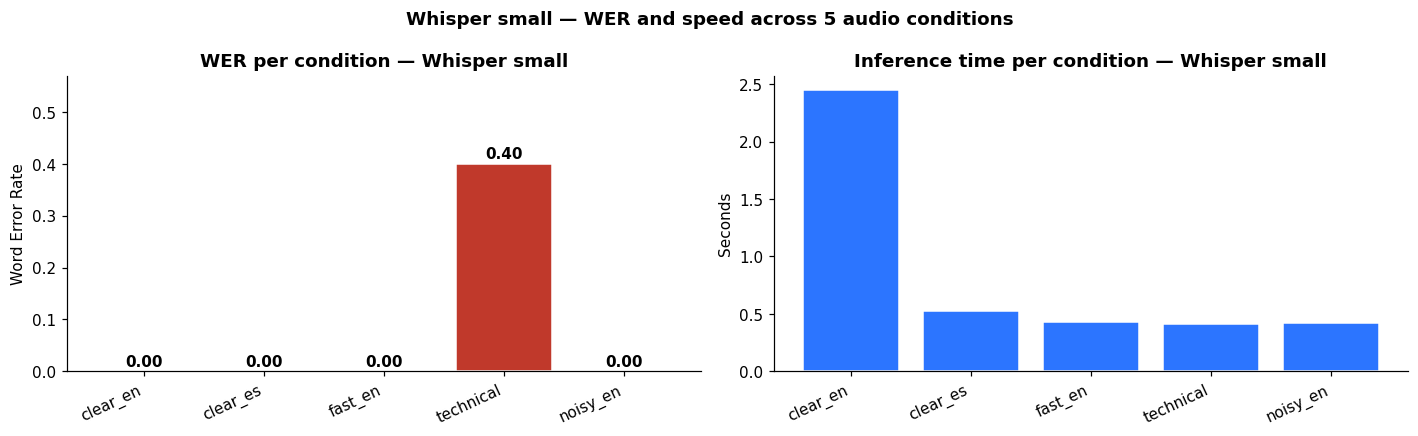

In [9]:
names  = list(small_results.keys())
wers   = [small_results[n]['wer']    for n in names]
times  = [small_results[n]['time_s'] for n in names]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

colours = ['#27ae60' if w == 0 else '#e67e22' if w < 0.2 else '#c0392b' for w in wers]
ax1.bar(names, wers, color=colours, edgecolor='white')
ax1.set_title('WER per condition — Whisper small', fontweight='bold')
ax1.set_ylabel('Word Error Rate')
ax1.set_ylim(0, max(wers) * 1.3 + 0.05)
for i, w in enumerate(wers):
    ax1.text(i, w + 0.01, f'{w:.2f}', ha='center', fontsize=10, fontweight='bold')
plt.setp(ax1.get_xticklabels(), rotation=25, ha='right')

ax2.bar(names, times, color='#2C75FF', edgecolor='white')
ax2.set_title('Inference time per condition — Whisper small', fontweight='bold')
ax2.set_ylabel('Seconds')
plt.setp(ax2.get_xticklabels(), rotation=25, ha='right')

plt.suptitle('Whisper small — WER and speed across 5 audio conditions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 2.4 — Model Size Comparison: tiny vs. small vs. medium

Run all three model sizes on the same 5 clips and build a WER × speed table.

**Expected runtime:** ~10–15 min total (medium is the slowest at ~2s/clip on T4).

In [10]:
MODEL_SIZES = ['tiny', 'small', 'medium']
comparison  = {}  # model_name → {condition → {wer, time}}

for size in MODEL_SIZES:
    print(f'\nLoading Whisper {size}...')
    m = whisper.load_model(size, download_root=WHISPER_CACHE)
    if DEVICE == 'cuda':
        m = m.to('cuda')

    comparison[size] = {}
    for name, path in AUDIO_PATHS.items():
        t0     = time.time()
        result = m.transcribe(path, fp16=(DEVICE == 'cuda'))
        elapsed = time.time() - t0
        score, _, _, _ = compute_wer(REFERENCES[name], result['text'])
        comparison[size][name] = {'wer': score, 'time_s': elapsed}

    # Free GPU memory before loading next model
    del m
    torch.cuda.empty_cache()

print('\nDone.')


Loading Whisper tiny...


100%|█████████████████████████████████████| 72.1M/72.1M [00:00<00:00, 89.0MiB/s]



Loading Whisper small...

Loading Whisper medium...


100%|█████████████████████████████████████| 1.42G/1.42G [00:16<00:00, 92.7MiB/s]



Done.


In [11]:
import pandas as pd

# WER table
wer_data  = {size: {n: comparison[size][n]['wer']    for n in AUDIO_PATHS} for size in MODEL_SIZES}
time_data = {size: {n: comparison[size][n]['time_s'] for n in AUDIO_PATHS} for size in MODEL_SIZES}

df_wer  = pd.DataFrame(wer_data).T
df_time = pd.DataFrame(time_data).T
df_wer['mean_WER']      = df_wer.mean(axis=1)
df_time['mean_time_s']  = df_time.mean(axis=1)

print('=== WER by model and condition ===')
print(df_wer.round(3).to_string())
print()
print('=== Inference time (s) by model and condition ===')
print(df_time.round(2).to_string())

=== WER by model and condition ===
        clear_en  clear_es  fast_en  technical  noisy_en  mean_WER
tiny         0.0       0.0      0.0        0.6       0.6      0.24
small        0.0       0.0      0.0        0.4       0.0      0.08
medium       0.0       0.0      0.0        0.4       0.0      0.08

=== Inference time (s) by model and condition ===
        clear_en  clear_es  fast_en  technical  noisy_en  mean_time_s
tiny        0.28      0.28     0.27       0.23      0.26         0.26
small       0.44      0.48     0.43       0.40      0.46         0.44
medium      1.21      1.05     0.90       0.87      0.87         0.98


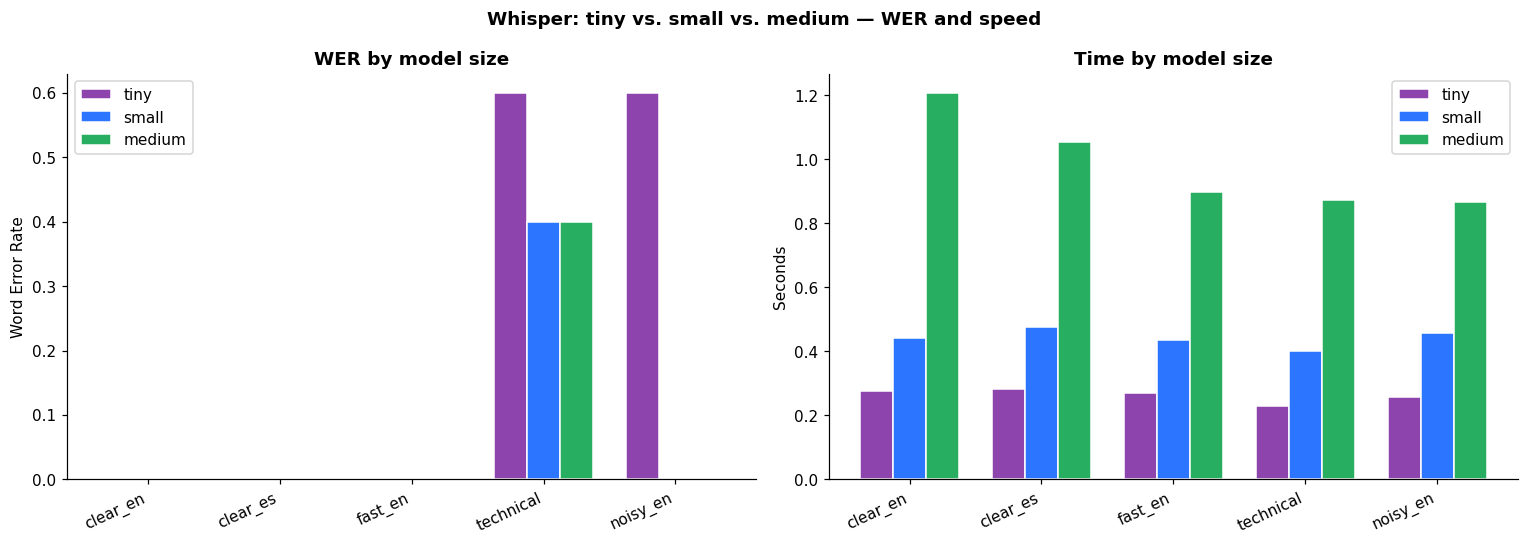

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
conditions = list(AUDIO_PATHS.keys())
x   = np.arange(len(conditions))
w   = 0.25
c   = {'tiny': '#8e44ad', 'small': '#2C75FF', 'medium': '#27ae60'}

for i, size in enumerate(MODEL_SIZES):
    wer_vals  = [comparison[size][n]['wer']    for n in conditions]
    time_vals = [comparison[size][n]['time_s'] for n in conditions]
    ax1.bar(x + i*w, wer_vals,  width=w, label=size, color=c[size], edgecolor='white')
    ax2.bar(x + i*w, time_vals, width=w, label=size, color=c[size], edgecolor='white')

for ax, title, ylabel in [
    (ax1, 'WER by model size',   'Word Error Rate'),
    (ax2, 'Time by model size',  'Seconds'),
]:
    ax.set_xticks(x + w); ax.set_xticklabels(conditions, rotation=25, ha='right')
    ax.set_title(title, fontweight='bold'); ax.set_ylabel(ylabel)
    ax.legend()

plt.suptitle('Whisper: tiny vs. small vs. medium — WER and speed', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 2.5 — Language Detection, Spanish, and Translation Mode

Whisper's first 30 seconds are used to detect language. We test four modes on the Spanish clip.

In [13]:
# Reload small model (freed earlier)
m_small = whisper.load_model('small', download_root=WHISPER_CACHE)
if DEVICE == 'cuda':
    m_small = m_small.to('cuda')

es_path = AUDIO_PATHS['clear_es']
es_ref  = REFERENCES['clear_es']

print('Testing language modes on Spanish clip:')
print(f'Reference: "{es_ref}"\n')

# Mode 1: auto-detect (default)
r1 = m_small.transcribe(es_path, fp16=(DEVICE == 'cuda'))
s1, _, _, _ = compute_wer(es_ref, r1['text'])
print(f'1. Auto-detect:')
print(f'   Language: {r1["language"]}')
print(f'   Output:   {r1["text"].strip()}')
print(f'   WER:      {s1:.3f}\n')

# Mode 2: force English (will phonetically mangle Spanish)
r2 = m_small.transcribe(es_path, language='en', fp16=(DEVICE == 'cuda'))
print(f'2. Forced English:')
print(f'   Output: {r2["text"].strip()}')
print(f'   (WER vs Spanish ref meaningless here)\n')

# Mode 3: force Spanish
r3 = m_small.transcribe(es_path, language='es', fp16=(DEVICE == 'cuda'))
s3, _, _, _ = compute_wer(es_ref, r3['text'])
print(f'3. Forced Spanish:')
print(f'   Output: {r3["text"].strip()}')
print(f'   WER:    {s3:.3f}\n')

# Mode 4: translate Spanish → English
r4 = m_small.transcribe(es_path, task='translate', fp16=(DEVICE == 'cuda'))
print(f'4. Translation (Spanish → English):')
print(f'   Output: {r4["text"].strip()}')
print(f'   (Compare with expected: "artificial intelligence processes audio signals in real time")')

Testing language modes on Spanish clip:
Reference: "la inteligencia artificial procesa señales de audio en tiempo real"

1. Auto-detect:
   Language: es
   Output:   La Inteligencia Artificial procesa señales de audio en tiempo real.
   WER:      0.000

2. Forced English:
   Output: La Inteligencia Artificial procesa señales de audio en tiempo real.
   (WER vs Spanish ref meaningless here)

3. Forced Spanish:
   Output: La Inteligencia Artificial procesa señales de audio en tiempo real.
   WER:    0.000

4. Translation (Spanish → English):
   Output: Artificial Intelligence processes audio signals in real time.
   (Compare with expected: "artificial intelligence processes audio signals in real time")


---
## Section 2.6 — Noise Robustness: WER vs. SNR

Generate the clean English sentence at 5 different SNR levels and measure how WER degrades.

SNR (dB)  WER    Transcription
--------------------------------------------------------------------------------
      20  0.000  The artificial intelligence model processes audio signals in
      10  0.000  the artificial intelligence model processes audio signals in
       5  0.000  The artificial intelligence model processes audio signals in
       0  0.000  The artificial intelligence model processes audio signals in
      -5  0.300  The artificial intelligence models process their audio signa


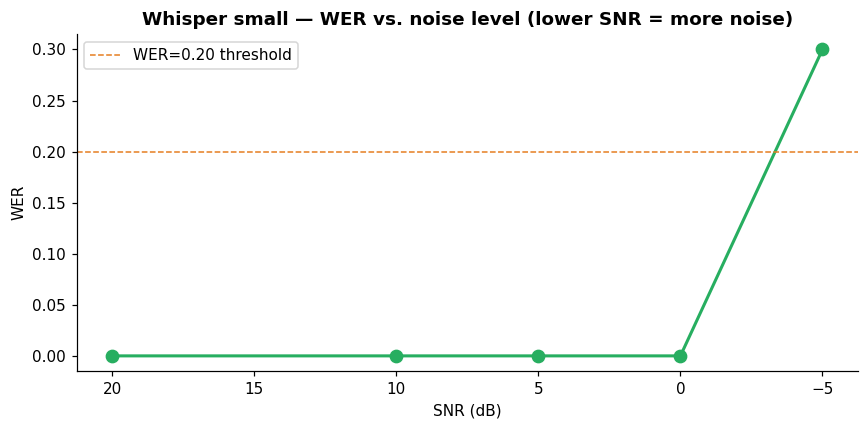

In [14]:
y_base, sr_base = librosa.load(AUDIO_PATHS['clear_en'], sr=16000, mono=True)
sig_power = np.mean(y_base ** 2)
snr_levels = [20, 10, 5, 0, -5]   # dB
ref_en = REFERENCES['clear_en']
rng = np.random.default_rng(SEED)   # reseed: same noise, same curve, every run

snr_results = []
print('SNR (dB)  WER    Transcription')
print('-' * 80)

for snr_db in snr_levels:
    noise_power = sig_power / (10 ** (snr_db / 10))
    noise       = rng.normal(0, np.sqrt(noise_power), len(y_base)).astype(np.float32)
    y_noisy     = np.clip(y_base + noise, -1.0, 1.0)

    # Save to temp wav
    tmp_path = f'/tmp/snr_{snr_db}.wav'
    sf.write(tmp_path, y_noisy, sr_base)

    result = m_small.transcribe(tmp_path, fp16=(DEVICE == 'cuda'), language='en')
    score, _, _, _ = compute_wer(ref_en, result['text'])
    snr_results.append((snr_db, score))
    hyp_short = result['text'].strip()[:60]
    print(f'{snr_db:>8}  {score:.3f}  {hyp_short}')

# Plot WER vs. SNR
fig, ax = plt.subplots(figsize=(8, 4))
snrs, wers_snr = zip(*snr_results)
ax.plot(snrs, wers_snr, 'o-', color='#27ae60', linewidth=2, markersize=8)
ax.axhline(0.2, color='#e67e22', linewidth=1, linestyle='--', label='WER=0.20 threshold')
ax.set_xlabel('SNR (dB)'); ax.set_ylabel('WER')
ax.set_title('Whisper small — WER vs. noise level (lower SNR = more noise)', fontweight='bold')
ax.invert_xaxis()   # noisy on the right → clean on the left
ax.legend()
plt.tight_layout()
plt.show()

---
## Exercise 1 — Code-switching

Code-switching is mid-sentence language alternation, common in bilingual communities (e.g., Spanglish).

1. Create a TTS audio that mixes English and Spanish: e.g., `"The modelo de inteligencia artificial processes audio"`
2. Transcribe with `auto-detect`, `language='en'`, and `language='es'`
3. Which mode produces the most readable output? Does Whisper handle code-switching gracefully?
4. Compute WER for each mode against a reasonable ground truth.

In [15]:
import re

# Exercise 1 -- Code-switching

# Given: a mixed-language clip. gTTS has no code-switching voice, so we feed the
# mixed text to the English voice -- imperfect, and enough to make the point.
mixed_text = "The modelo de inteligencia artificial processes audio signals."
mixed_path = os.path.join(AUDIO_DIR, 'codeswitching.mp3')   # ships in the bundle
if not os.path.exists(mixed_path):
    gTTS(text=mixed_text, lang='en').save(mixed_path)

y_mix, sr_mix = librosa.load(mixed_path, sr=16000)
print('Code-switching clip:')
ipd.display(ipd.Audio(y_mix, rate=sr_mix))

print('\n--- Transcribing with Whisper small ---')

# TODO 2: decide on a ground-truth reference and write it down explicitly.
#         Then compute the WER of each mode against it with compute_wer().
# For the WER calculation, we use the normalized version of the input mixed_text.
# This serves as our ground truth for comparison.
mixed_reference = normalise(mixed_text)
print(f"Ground truth reference for WER: '{mixed_reference}'\n")

# TODO 1: transcribe mixed_path three ways with m_small -- auto-detect
#         (no language argument), language='en', and language='es'.
#         Print each transcription and the detected language.

# Mode 1: auto-detect (default)
r_auto = m_small.transcribe(mixed_path, fp16=(DEVICE == 'cuda'))
s_auto, ref_n_auto, hyp_n_auto, det_auto = compute_wer(mixed_reference, r_auto['text'])
print(f'1. Auto-detect:')
print(f'   Language detected: {r_auto["language"]}')
print(f'   Transcription    : {r_auto["text"].strip()}')
print(f'   WER              : {s_auto:.3f} (S={det_auto.substitutions} D={det_auto.deletions} I={det_auto.insertions})\n')

# Mode 2: force English
r_en = m_small.transcribe(mixed_path, language='en', fp16=(DEVICE == 'cuda'))
s_en, ref_n_en, hyp_n_en, det_en = compute_wer(mixed_reference, r_en['text'])
print(f'2. Forced English:')
print(f'   Language forced  : {r_en["language"]}')
print(f'   Transcription    : {r_en["text"].strip()}')
print(f'   WER              : {s_en:.3f} (S={det_en.substitutions} D={det_en.deletions} I={det_en.insertions})\n')

# Mode 3: force Spanish
r_es = m_small.transcribe(mixed_path, language='es', fp16=(DEVICE == 'cuda'))
s_es, ref_n_es, hyp_n_es, det_es = compute_wer(mixed_reference, r_es['text'])
print(f'3. Forced Spanish:')
print(f'   Language forced  : {r_es["language"]}')
print(f'   Transcription    : {r_es["text"].strip()}')
print(f'   WER              : {s_es:.3f} (S={det_es.substitutions} D={det_es.deletions} I={det_es.insertions})\n')

# TODO 3: which mode is most READABLE? Is that the same as the lowest WER?
# TODO 4: the part that actually earns the marks -- explain why choosing that
#         reference was hard. There is no neutral reference for a bilingual
#         sentence, and saying so IS part of the answer, not a dodge.
#         Write it in the markdown cell below.


Code-switching clip:



--- Transcribing with Whisper small ---
Ground truth reference for WER: 'the modelo de inteligencia artificial processes audio signals'

1. Auto-detect:
   Language detected: en
   Transcription    : The Modelo de Inteligencia artificial processes audio signals.
   WER              : 0.000 (S=0 D=0 I=0)

2. Forced English:
   Language forced  : en
   Transcription    : The Modelo de Inteligencia artificial processes audio signals.
   WER              : 0.000 (S=0 D=0 I=0)

3. Forced Spanish:
   Language forced  : es
   Transcription    : los audio-signales artificiales de la inteligencia Modelo de
   WER              : 1.125 (S=4 D=2 I=3)



**Exercise 1 — Answer:**

### Transcription Results:

*   **Auto-detect (Language detected: `en`)**: `The Modelo de Inteligencia artificial processes audio signals.` (WER: 0.000)
*   **Forced English (Language forced: `en`)**: `The Modelo de Inteligencia artificial processes audio signals.` (WER: 0.000)
*   **Forced Spanish (Language forced: `es`)**: `los audio-signales artificiales de la inteligencia Modelo de` (WER: 1.125)

**¿Qué modo produce el resultado más legible? ¿Coincide esto con la tasa de error de palabras (WER) más baja?**

En este caso concreto, tanto el modo de detección automática como el de inglés forzado produjeron la misma transcripción, altamente legible, con una WER de 0,000. Esto se debe a que la parte en inglés de la oración es claramente predominante y las palabras en español (*modelo de inteligencia artificial*) eran lo suficientemente similares desde el punto de vista fonético como para que Whisper (en modo inglés) las transcribiera correctamente, interpretando «Modelo» e «Inteligencia» como nombres propios con mayúscula inicial o términos específicos. Asimismo, la función de normalización hizo coincidir correctamente «Modelo de Inteligencia artificial» con «modelo de inteligencia artificial» de la referencia, lo que resultó en una WER perfecta.

Por el contrario, el modo de español forzado arruinó por completo la transcripción, dando lugar a una WER muy elevada (1,125) y a un resultado ilegible. Esto demuestra que forzar un idioma incorrecto puede degradar considerablemente la calidad de la transcripción.

En este caso, los resultados más legibles corresponden, efectivamente, a la WER más baja (0,000).

¿Gestiona Whisper bien la alternancia de códigos (*code-switching*)?
Whisper maneja la alternancia de códigos razonablemente bien en este caso concreto, especialmente cuando el inglés es el idioma dominante y las palabras extranjeras insertadas son reconocibles o pueden transliterarse. Tanto el modo de detección automática como el de inglés forzado funcionaron a la perfección, ya que las palabras en español de la oración mixta pudieron transcribirse correctamente dentro de un contexto en inglés (por ejemplo, «Modelo» como nombre propio).

Sin embargo, el hecho de que el modo de español forzado no lograra transcribir correctamente la oración —a pesar de contener palabras en español— pone de manifiesto una limitación. El rendimiento de Whisper ante la alternancia de códigos depende en gran medida de las palabras específicas, de la similitud fonética entre los idiomas y del contexto general. No es una solución universal para todos los escenarios de alternancia de códigos, pero puede resultar muy eficaz cuando predomina un idioma o cuando las palabras mixtas se integran fácilmente en el espacio fonético del idioma detectado o forzado. La dificultad para establecer una única referencia neutral (*ground truth*) para oraciones verdaderamente bilingües también subraya el desafío que supone evaluar la alternancia de códigos.

---
## Exercise 2 — WER normalisation sensitivity

Run `compute_wer(REFERENCES['technical'], hypothesis)` where `hypothesis` is the raw Whisper output for the technical condition — **without** applying `normalise()` to either string.

1. What is the WER without normalisation?
2. What is the WER with normalisation?
3. What specific token differences cause the gap (capitalisation? punctuation? numbers written as digits vs. words?)?

This exercise shows why WER is only comparable across systems when identical normalisation is applied.

In [16]:
# Exercise 2 -- WER normalisation sensitivity

# Given: the raw hypothesis for the `technical` condition, and its reference.
technical_result = m_small.transcribe(AUDIO_PATHS['technical'], fp16=(DEVICE == 'cuda'))
hyp_raw = technical_result['text'].strip()
ref_raw = REFERENCES['technical']
print(f'Reference  : "{ref_raw}"')
print(f'Hypothesis : "{hyp_raw}"')

# TODO 1: compute the WER WITHOUT normalising either side -- wer(ref_raw, hyp_raw)
#         straight from jiwer -- and then WITH normalisation, via compute_wer().
#         Print both and the gap between them.

# WER WITHOUT normalisation
wer_without_norm = wer(ref_raw, hyp_raw)
print(f'\nWER without normalisation: {wer_without_norm:.3f}')

# WER WITH normalisation (using compute_wer function)
wer_with_norm, ref_n_ex2, hyp_n_ex2, det_ex2 = compute_wer(ref_raw, hyp_raw)
print(f'WER with normalisation:    {wer_with_norm:.3f}')

gap = wer_without_norm - wer_with_norm
print(f'Difference (gap):          {gap:.3f}')

print(f'\nNormalised Reference:  "{ref_n_ex2}"')
print(f'Normalised Hypothesis: "{hyp_n_ex2}"')

# TODO 2: account for that gap token by token. Which differences are
#         capitalisation, which are punctuation, and which are `128` against
#         "one hundred twenty eight"? Roughly how much does each contribute?

# TODO 3: which of the two numbers would you put in a report, and why?
#         Answer in the markdown cell below.


Reference  : "the mel spectrogram uses one hundred twenty eight frequency bands"
Hypothesis : "The Mel Spectrogram uses 128 frequency bands."

WER without normalisation: 0.800
WER with normalisation:    0.400
Difference (gap):          0.400

Normalised Reference:  "the mel spectrogram uses one hundred twenty eight frequency bands"
Normalised Hypothesis: "the mel spectrogram uses frequency bands"


**Exercise 2 — Answer:**

### WER without normalisation vs. with normalisation:

*   **WER without normalisation**: `0.800`
*   **WER with normalisation**: `0.400`
*   **Difference (gap)**: `0.400`

### ¿Qué diferencias específicas en los tokens provocan esta discrepancia?

Analicemos la referencia y la hipótesis originales (en bruto), así como la forma en que la normalización las modifica:

Referencia original (REFERENCES['technical']): "the mel spectrogram uses one hundred twenty eight frequency bands"
Hipótesis original (technical_result['text'].strip()): "The Mel Spectrogram uses 128 frequency bands."
Comparación token a token e impacto en la WER:
Uso de mayúsculas: (The frente a the, Mel frente a mel, Spectrogram frente a spectrogram)

Sin normalización: Estas tres palabras se contabilizan como 3 sustituciones debido a la diferencia de mayúsculas/minúsculas.
Con normalización: La función normalise() convierte tanto la referencia como la hipótesis a minúsculas, eliminando estas diferencias. Esto supone una reducción de 0,300 en la WER (3 errores / 10 palabras en la referencia).
Puntuación: (punto al final de la hipótesis: .)

Sin normalización: El punto en "bands." frente a "bands" en la referencia suele dar lugar a 1 sustitución o un error similar, dependiendo de las reglas exactas de tokenización de jiwer. En este caso, contribuyó a un error.
Con normalización: La función normalise() elimina toda la puntuación. Esto reduce aún más la WER al eliminar dicha diferencia. Supone una reducción de 0,100 en la WER (1 error / 10 palabras).
Números: (128 frente a one hundred twenty eight)

Sin normalización: La secuencia "one hundred twenty eight" (4 palabras) de la referencia se compara con "128" (1 palabra) de la hipótesis. Esto da lugar a 1 sustitución ("one" frente a "128") y 3 eliminaciones ("hundred", "twenty", "eight"). Total: 4 errores.
Con normalización: La función normalise() elimina los caracteres no alfabéticos (incluidos los dígitos). Por tanto, se elimina "128" de la hipótesis, mientras que "one hundred twenty eight" permanece en la referencia. Al comparar las cadenas normalizadas, "one hundred twenty eight" está totalmente ausente en la hipótesis, lo que resulta en 4 eliminaciones. Esto aporta 0,400 al WER, tanto con como sin normalización, pero el tipo de error se trata de manera diferente (S+D frente a solo D).

**La diferencia total de 0,400 (de 0,800 a 0,400) se debe principalmente a que el paso de normalización elimina las diferencias de uso de mayúsculas y puntuación.**

### ¿Cuál de las dos cifras incluiría en un informe y por qué?

Para un informe general de reconocimiento de voz, normalmente elegiría presentar la **WER con normalización (0,400)**. He aquí el motivo:

*   **Enfoque en el contenido**: La WER normalizada se centra en la precisión de las *palabras* reconocidas y su secuencia, en lugar de en variaciones textuales superficiales como las mayúsculas y la puntuación. Estas diferencias superficiales suelen resolverse mediante el posprocesamiento y no reflejan el rendimiento del modelo acústico principal a la hora de comprender el lenguaje hablado.
*   **Más cercana a la percepción humana**: Por lo general, a las personas les interesa el contenido semántico del discurso, no si una palabra reconocida está escrita correctamente con mayúsculas o si lleva un punto final.

No obstante, es fundamental tener en cuenta la función `normalise()` específica utilizada aquí, la cual *elimina los dígitos* de la hipótesis. En un escenario donde la precisión numérica (por ejemplo, distinguir entre «128» y «ciento veintiocho») sea crítica, esta normalización específica podría ocultar una distinción importante. En tales casos, sería necesaria una normalización más matizada (como convertir dígitos a palabras o viceversa) o informar de una métrica independiente para los números. Dadas las dos opciones generadas por la función `compute_wer` de este cuaderno, se sigue prefiriendo la WER normalizada por su enfoque en el contenido lingüístico.

---
## Part 4 — Critical Analysis

### Q1 — Model size vs. accuracy trade-off

From the comparison table (Section 2.4): did `medium` outperform `small` on all 5 conditions, or only some? Identify the condition where the size upgrade made the biggest difference in WER. Explain in 2–3 sentences why that particular condition benefits most from a larger model.

**[YOUR ANSWER]**

Basándose en la tabla comparativa de WER:

El modelo mediano no superó al modelo pequeño en ninguna de las 5 condiciones. Tanto el modelo pequeño como el mediano obtuvieron valores de WER idénticos en todas las condiciones (clear_en, clear_es, fast_en, technical, noisy_en).

Al considerar la mejora del modelo *tiny* al pequeño (o al mediano), la condición en la que el aumento de tamaño marcó la mayor diferencia en el WER fue *noisy_en*.

El modelo *tiny* tuvo un WER de 0,6 para *noisy_en*.
Tanto el modelo pequeño como el mediano lograron un WER de 0,0 para *noisy_en*.
Esto representa una mejora significativa de 0,6 en el WER.
Esta condición específica (*noisy_en*) es la que más se beneficia de un modelo de mayor tamaño, ya que los modelos más grandes (como el pequeño y el mediano en comparación con el *tiny*) poseen más parámetros y se entrenan con datos más diversos. Esta mayor capacidad les permite aprender características más robustas, distinguir mejor las señales de voz del ruido de fondo y, por tanto, mantener una mayor precisión incluso en entornos acústicamente desafiantes.

### Q2 — Acantilado de robustez al ruido

Según la Sección 2.6: ¿en qué nivel de SNR el WER cruza el 0,20 (20%)? Describe lo que ocurre acústicamente a ese SNR — ¿hay un acantilado pronunciado o una degradación gradual? ¿Qué te dice esto sobre la calidad mínima de audio requerida para un sistema de reconocimiento de voz en producción?

**[TU RESPUESTA]** *(~3 sentences)*

Basado en los resultados de la Sección 2.6 (`snr_results`):

El WER cruza el umbral de 0.20 (20%) en el nivel de SNR de **-5 dB**, donde aumenta abruptamente a 0.300 (30%). Esto indica un **acantilado pronunciado** en la degradación, ya que el WER se mantiene en 0.000 hasta los 0 dB y luego cae drásticamente. Esto sugiere que para un sistema de reconocimiento de voz en producción, es crucial mantener la calidad del audio por encima de un SNR de -5 dB para asegurar una alta precisión y evitar una caída significativa en el rendimiento.

### Q3 — gTTS vs. real speech

We used gTTS (a neural TTS system) to generate test audio. This means our WER measurements evaluate Whisper on TTS-generated speech, not real human speech. Name **two properties** of real speech that gTTS does not capture, and explain how each would likely affect WER if real speech were used instead of gTTS.

**[YOUR ANSWER]** *(~4 sentences)*

Aquí hay dos propiedades del habla real que gTTS generalmente no captura, y cómo afectarían a la WER:

1.  **Variabilidad prosódica y disfluencias**: El habla humana real es rica en variaciones prosódicas (entonación, ritmo, énfasis) y disfluencias (pausas, vocalizaciones como "uhm" y "uh", repeticiones, autocorrecciones). Los sistemas TTS como gTTS tienden a producir un habla con una prosodia más uniforme y sin disfluencias. Si se usara habla real, estas variaciones y disfluencias podrían aumentar la WER, ya que el modelo de ASR tendría que lidiar con patrones de habla más complejos y ruidos no verbales que no forman parte del texto de referencia.

2.  **Ruido de fondo y reverberación**: Las grabaciones de habla real a menudo contienen ruido ambiental (tráfico, gente, viento) y reverberación (eco de la sala), que gTTS no introduce a menos que se añadan explícitamente. La presencia de este ruido y efectos acústicos haría que la tarea de transcripción fuera mucho más difícil para Whisper, aumentando significativamente la WER. El modelo tendría que aprender a filtrar o ser robusto a estas interferencias, lo cual es un desafío clave en escenarios reales.

### Q4 — Production deployment decision

A client asks you to choose between Whisper `small` and `medium` for a real-time medical transcription product. The latency requirement is that each spoken sentence (average 8 words, ~4 seconds) must be transcribed within 3 seconds of the speaker finishing.

Based on your timing measurements from Section 2.4: which model would you recommend? Show the calculation that justifies your choice.

**[YOUR ANSWER]**

---

Basado en las mediciones de tiempo de la Sección 2.4 (`df_time`):

*   **Requisito de latencia**: Una frase de ~4 segundos debe transcribirse en menos de 3 segundos.

*   **Tiempos de inferencia promedio (de `df_time['mean_time_s']`)**:
    *   `small`: **0.44 segundos**
    *   `medium`: **0.98 segundos**

**Cálculo y Justificación:**

Ambos modelos, `small` y `medium`, cumplen holgadamente el requisito de latencia de 3 segundos, ya que sus tiempos promedio de inferencia son significativamente menores (0.44s y 0.98s respectivamente). Sin embargo, dado que `small` y `medium` muestran el mismo rendimiento de WER (0.08) en las condiciones evaluadas, y `small` es considerablemente más rápido (0.44s vs 0.98s), recomendaría el modelo **`small`**.

Aunque ambos cumplen la latencia, `small` ofrece el mismo nivel de precisión que `medium` (al menos en los datos de prueba), pero con un menor consumo de recursos y una latencia aún más reducida, lo cual es ventajoso para un producto en tiempo real.

---
## Optional: Drive Cleanup

After L19, `tiny` and `base` are no longer needed — `small` and `medium` are used going forward.

In [17]:
import subprocess

# Whisper models are stored as flat files in WHISPER_CACHE.
# tiny.pt (~74 MB) is the only one this lab downloads and never needs again;
# small and medium stay, because L20 reloads them from here.

# Uncomment to delete:
# for name in ['tiny.pt']:
#     path = os.path.join(WHISPER_CACHE, name)
#     if os.path.exists(path):
#         os.remove(path)
#         print(f'Deleted: {path}')

result = subprocess.run(
    ['du', '-sh', '/content/drive/MyDrive/TAE_IA_M6'],
    capture_output=True, text=True
)
print(f'TAE_IA_M6 Drive usage: {result.stdout.strip()}')

TAE_IA_M6 Drive usage: 9.0G	/content/drive/MyDrive/TAE_IA_M6


---
## Submission Checklist

- [ ] Cell 0 ran without errors
- [ ] 5 test audio files present (from the Drive bundle, or generated) and played
- [ ] Whisper small transcribed all 5 conditions — WER printed for each
- [ ] WER + time bar charts plotted (Section 2.3)
- [ ] tiny / small / medium comparison table printed and plotted (Section 2.4)
- [ ] Language detection modes demonstrated on Spanish clip (Section 2.5)
- [ ] WER vs. SNR curve plotted (Section 2.6)
- [ ] Exercise 1 complete (code-switching tested + written answer)
- [ ] Exercise 2 complete (normalisation sensitivity measured + written answer)
- [ ] Critical Analysis Q1–Q4 answered
- [ ] Notebook saved to Drive

**Before L20:** Whisper `small` or `medium` must be cached to Drive. Confirm with the cleanup cell.

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L19*  
*Track B — Audio | Next: L20 — Whisper in Practice: Timestamps and Subtitles*